In [15]:
from diffusers import UNet2DModel
import torch
model_id = "google/ddpm-cifar10-32"
gen = UNet2DModel.from_pretrained(model_id)
gen = gen.to()

from diffusers import DDPMScheduler

scheduler = DDPMScheduler.from_config(model_id)

try: 
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.xla_multiprocessing as xmp
except: pass

from models import load_model
from utils.utils import *
from utils.utils_data import *
from utils.utils_ebm import *
from utils.utils_baselines import *


/home/sunaybhat/.local/lib/python3.8/site-packages/diffusers/configuration_utils.py:244: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


In [16]:
scheduler.config

FrozenDict([('num_train_timesteps', 1000),
            ('beta_start', 0.0001),
            ('beta_end', 0.02),
            ('beta_schedule', 'linear'),
            ('trained_betas', None),
            ('variance_type', 'fixed_large'),
            ('clip_sample', True),
            ('prediction_type', 'epsilon'),
            ('thresholding', False),
            ('dynamic_thresholding_ratio', 0.995),
            ('clip_sample_range', 1.0),
            ('sample_max_value', 1.0),
            ('timestep_spacing', 'leading'),
            ('steps_offset', 0),
            ('rescale_betas_zero_snr', False),
            ('_use_default_values',
             ['thresholding',
              'dynamic_thresholding_ratio',
              'steps_offset',
              'rescale_betas_zero_snr',
              'clip_sample_range',
              'timestep_spacing',
              'prediction_type',
              'sample_max_value']),
            ('_class_name', 'DDPMScheduler'),
            ('_diffusers_versi

In [20]:
scheduler.config['num_train_timesteps'] = 100  # Reduced number of diffusion steps
scheduler.config['beta_start'] = .00001  # Starting noise level
scheduler.config['beta_end'] = 0.00002  # You may need to adjust this based on performance
scheduler.config['beta_schedule'] = 'linear'  # Consider experimenting with 'cosine' or custom schedules
# Additional configurations here if needed

scheduler.save_config("my_scheduler")
scheduler = DDPMScheduler.from_config("my_scheduler")


In [18]:
train_data = torchvision.datasets.CIFAR10(root='/home/sunaybhat/data', train=True, download=True, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
batch_1,_ = next(iter(train_loader))
image_1 = batch_1[0].unsqueeze(0)

Files already downloaded and verified


100%|██████████| 100/100 [00:09<00:00, 10.34it/s]


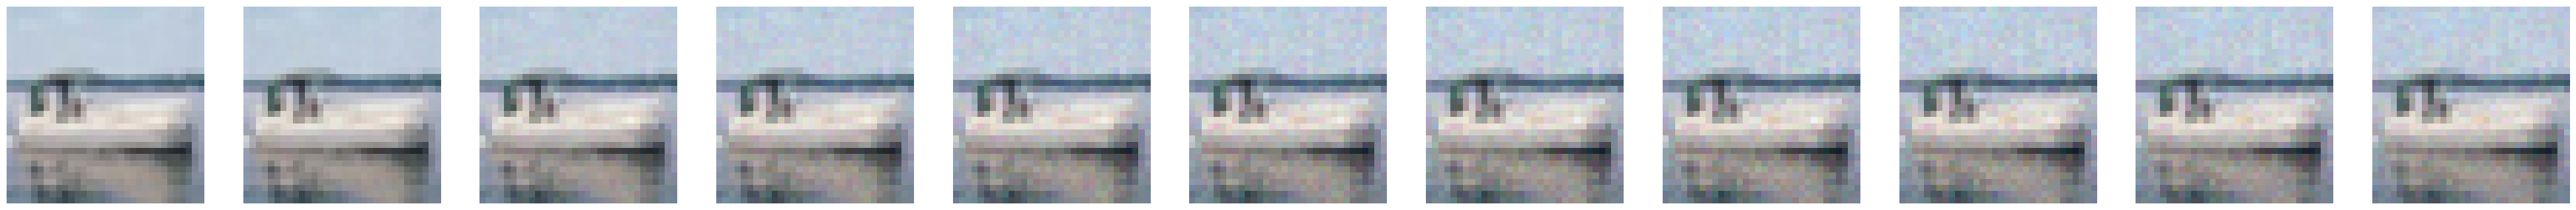

In [21]:
import matplotlib.pyplot as plt

# Initialize an empty list to store the images
samples = [image_1.cpu().squeeze().permute(1, 2, 0)]

sample = image_1.to(gen.device)

for i, t in enumerate(tqdm(scheduler.timesteps)):
  # print(t)
  # 1. predict noise residual
  with torch.no_grad():
    residual = gen(sample, t).sample

  # 2. compute less noisy image and set x_t -> x_t-1
  sample = scheduler.step(residual, t, sample).prev_sample

  # Store the sample in the list
  image_clipped = torch.clamp(sample, -1, 1).cpu().squeeze().permute(1, 2, 0)
  if i % 10 == 0:
    samples.append(image_clipped)

# Create a figure with a number of subplots equal to the number of samples
fig, axs = plt.subplots(1, len(samples), figsize=(50, 100))

# Plot 10 even spaces sampled

for i, sample in enumerate(samples):
  axs[i].imshow(sample)  # replace with the appropriate function to display your images
  axs[i].axis('off')  # remove axes for clarity

